In [ ]:
# ============================================================
# INSTALL ALL DEPENDENCIES - Run this first, then restart kernel
# ============================================================

# Core image & PDF processing
!pip install pillow opencv-python-headless pypdf pdf2image

# PaddleOCR
!pip install paddlepaddle paddleocr

# LayoutLM / Transformers
!pip install transformers torch sentencepiece

# LangChain - pinned compatible versions
!pip install "langchain==0.2.16" "langchain-core==0.2.43" "langchain-groq==0.1.9"

# Groq (VLM + agent LLM)
!pip install groq

# Env management
!pip install python-dotenv

# Matplotlib
!pip install matplotlib

In [2]:
import os
from dotenv import load_dotenv
import os

load_dotenv()  # loads variables from .env into environment

# Optional: verify it loaded (won't print the actual key)
print("API key loaded:", "GOOGLE_API_KEY" in os.environ)

API key loaded: True


In [3]:
from dotenv import load_dotenv
_ = load_dotenv(override=True)

from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Any
import base64
from io import BytesIO
import urllib.request

In [4]:
from paddleocr import PaddleOCR, LayoutDetection

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [5]:
from transformers import LayoutLMv3ForTokenClassification
from langchain.tools import tool


In [6]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Any

In [7]:
from pypdf import PdfReader, PdfWriter

# Load PDF
reader = PdfReader("State_of_Working_India_2023_ebook_revised.pdf")
writer = PdfWriter()

# Extract page (index starts at 0)
page_number = 22

writer.add_page(reader.pages[page_number])

with open("extracted_page.pdf", "wb") as f:
    writer.write(f)

# Display the extracted page
from IPython.display import display, IFrame
display(IFrame("extracted_page.pdf", width=700, height=900))


# -------- Convert PDF page to image --------
from pdf2image import convert_from_path

pages = convert_from_path(
    "extracted_page.pdf",
    dpi=300,
    poppler_path=r"C:\Users\Admin\Downloads\Release-25.12.0-0\poppler-25.12.0\Library\bin"
)

# Save image
image_path = "page23.png"
pages[0].save(image_path, "PNG")

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_

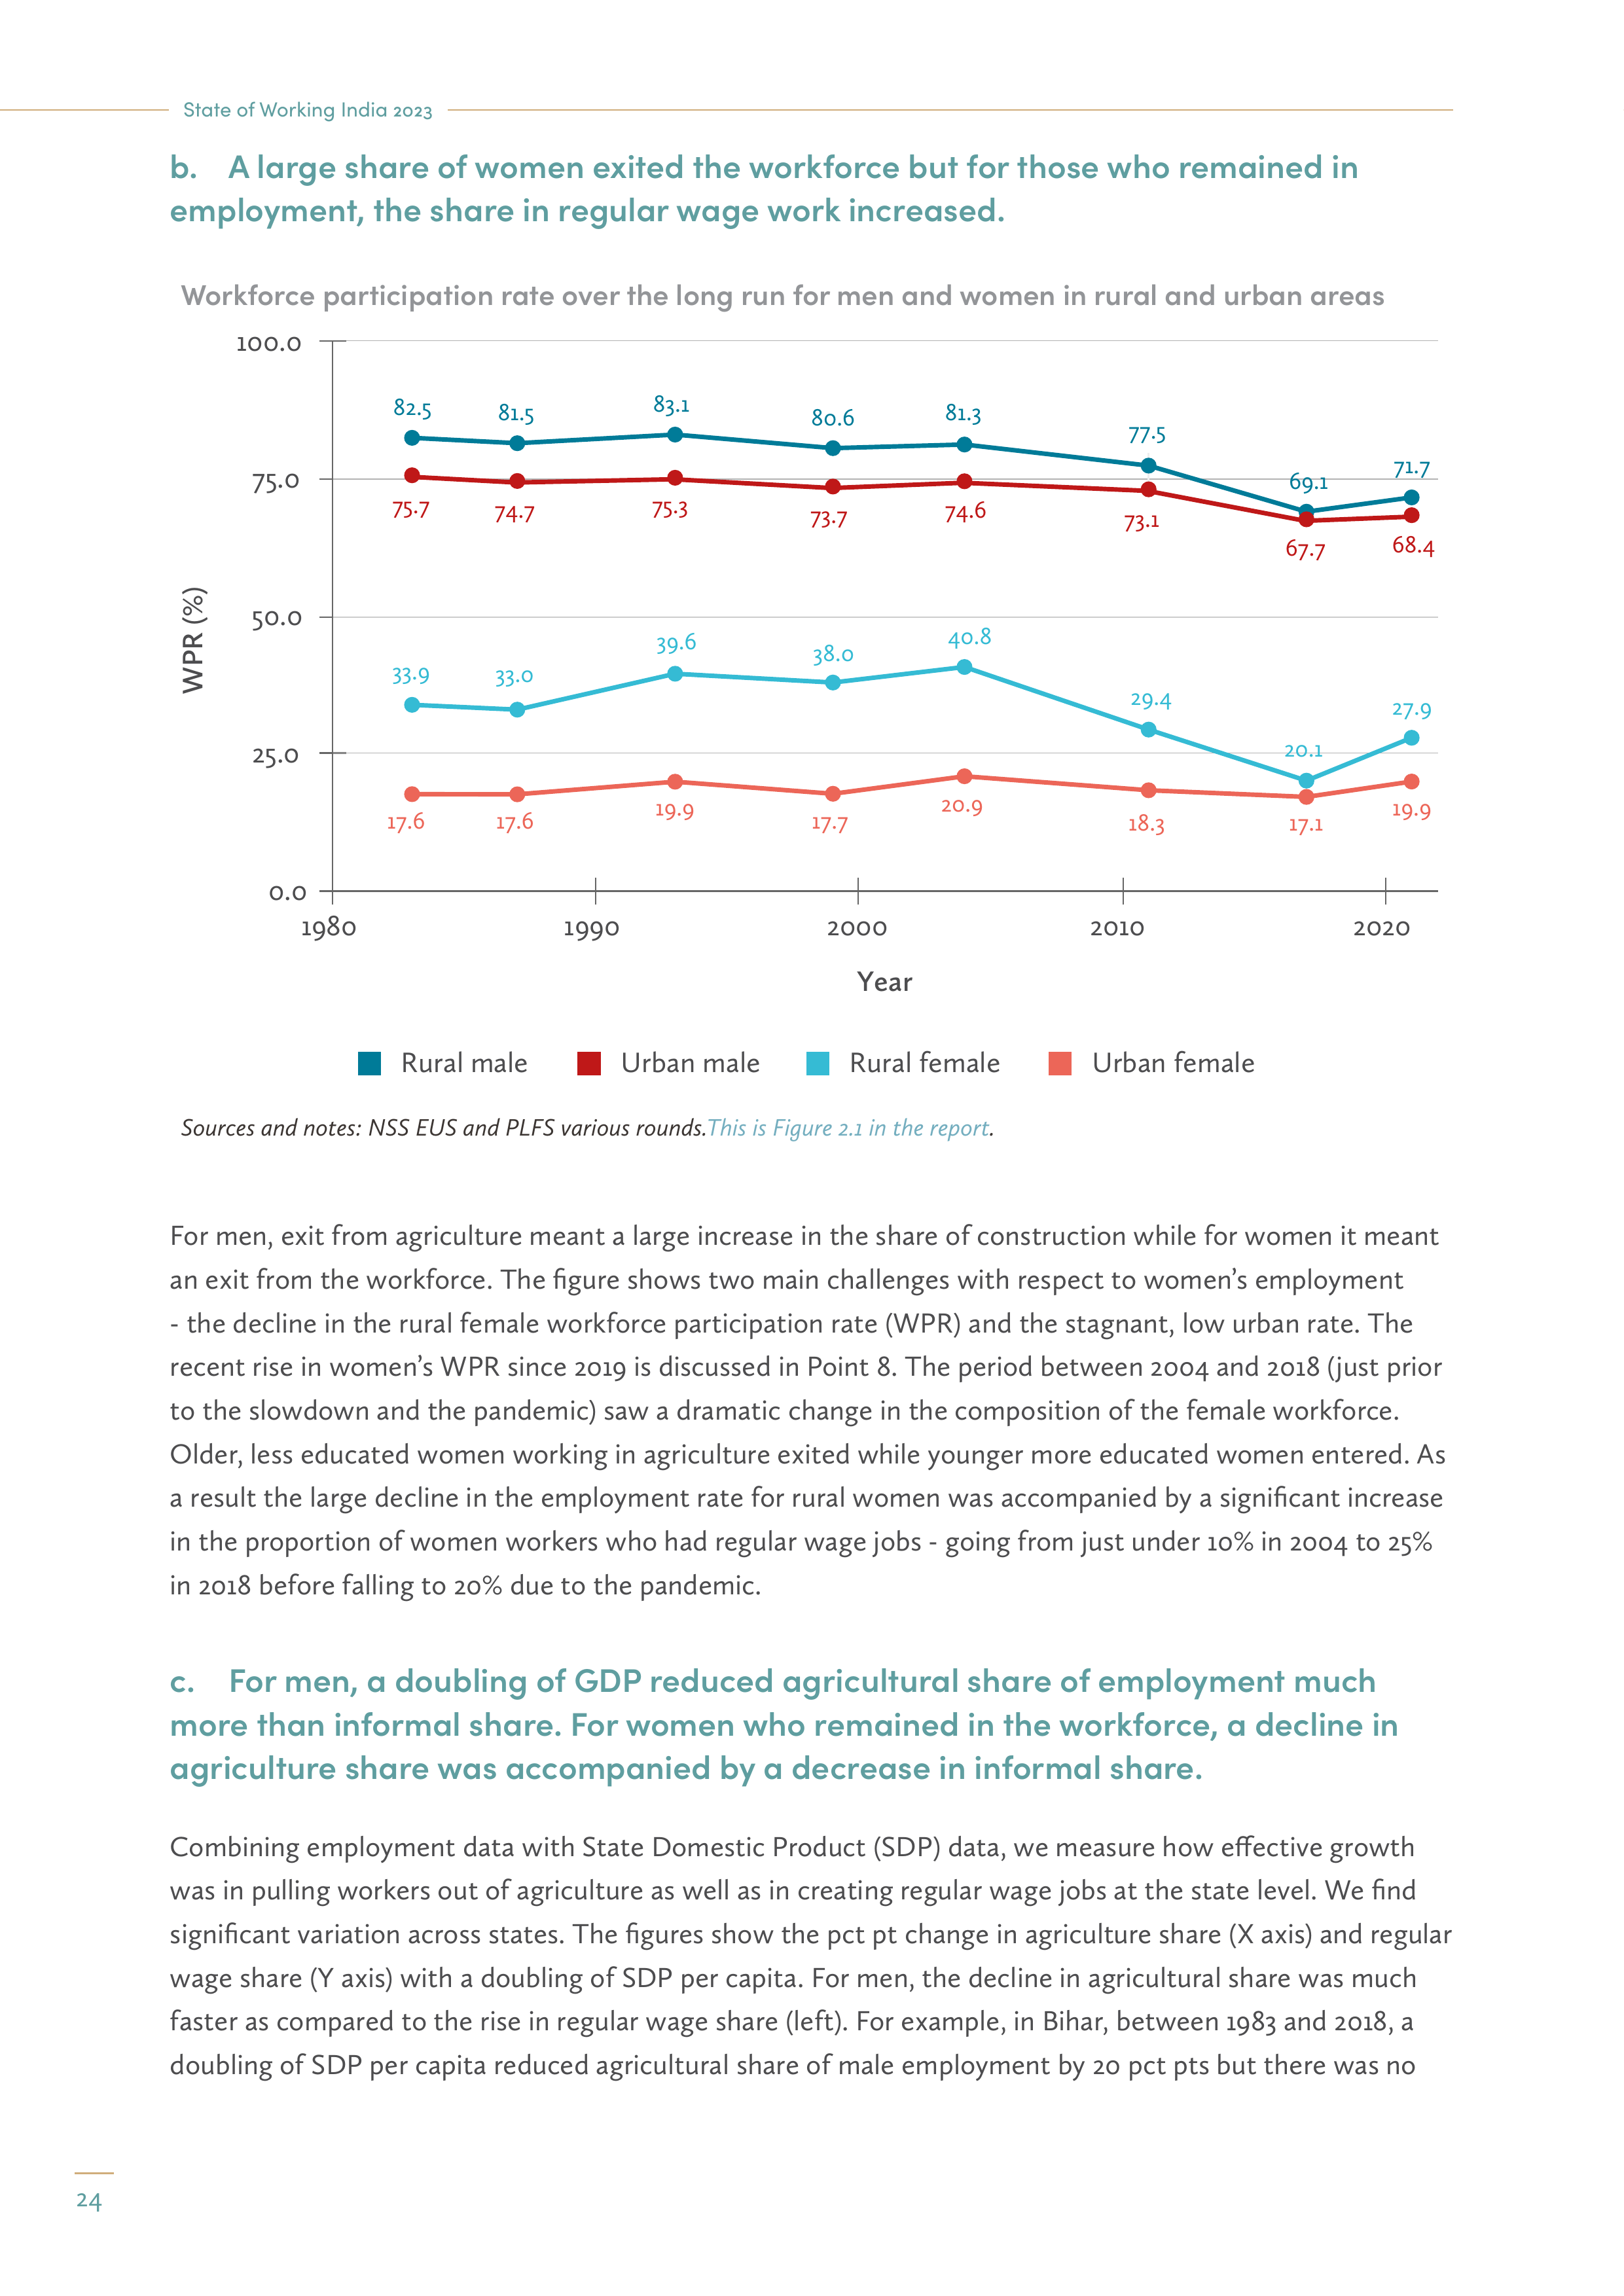

In [8]:
from paddleocr import PaddleOCR

# Initialize PaddleOCR 
ocr = PaddleOCR(
    use_textline_orientation=True,
    lang='en',
    text_det_thresh=0.3,
    text_det_box_thresh=0.4,
    text_det_unclip_ratio=2.0,
    text_det_limit_side_len=2400,
)

# Load image
image_path = "page23.png"
display(Image.open(image_path))

In [9]:
# Run OCR 
result = ocr.predict(image_path)
page = result[0]


texts = page['rec_texts']      # recognized text strings
scores = page['rec_scores']    # confidence scores
boxes = page['rec_polys']      # bounding box coordinates

print(f"Extracted {len(texts)} text regions")
print("\nFirst 10 regions:")
for text, score, box in list(zip(texts, scores, boxes))[:10]:
    coords = box.astype(int).tolist()
    print(f"{text:40} | {score:.3f} | {coords}")

Extracted 99 text regions

First 10 regions:
b.                                       | 1.000 | [[160, 39], [216, 39], [216, 97], [160, 97]]
A large                                  | 0.999 | [[258, 38], [465, 51], [460, 123], [254, 110]]
share                                    | 1.000 | [[464, 54], [615, 58], [613, 112], [463, 108]]
of                                       | 1.000 | [[622, 62], [682, 62], [682, 109], [622, 109]]
women                                    | 0.981 | [[677, 61], [871, 59], [872, 107], [677, 110]]
exited                                   | 1.000 | [[880, 57], [1041, 57], [1041, 111], [880, 111]]
the                                      | 1.000 | [[1048, 57], [1136, 57], [1136, 111], [1048, 111]]
workforce but for those who remained in  | 0.989 | [[1136, 53], [2199, 78], [2198, 144], [1135, 119]]
−                                        | 0.599 | [[673, 83], [685, 75], [693, 88], [681, 96]]
employment,                              | 1.000 | [[155, 111], [50

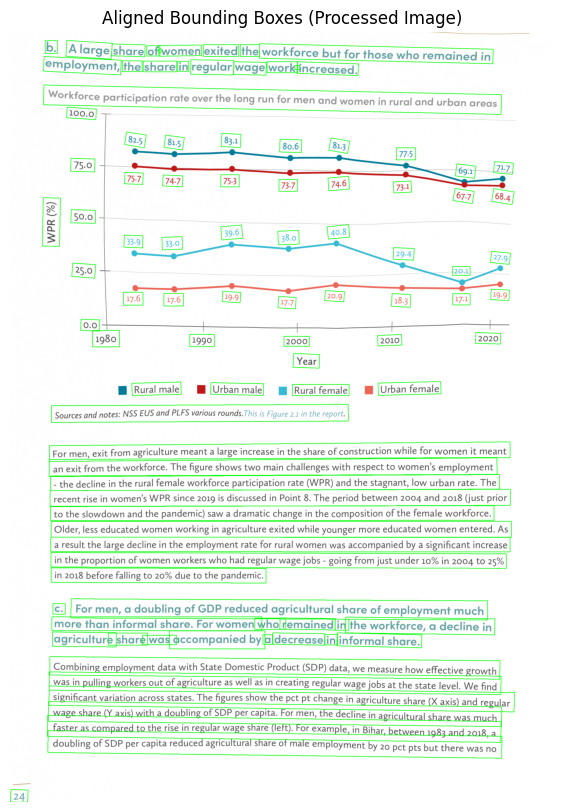

In [10]:
processed_img = page['doc_preprocessor_res']['output_img']
img_plot = processed_img.copy()
show_text= False

for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    if show_text:
        cv2.putText(img_plot, text, (x, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (Processed Image)")
plt.show()

In [11]:
# Store OCR results in a structured format
@dataclass
class OCRRegion:
    text: str
    bbox: list  # [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
    confidence: float
    
    @property
    def bbox_xyxy(self):
        """Return bbox as [x1, y1, x2, y2] format."""
        x_coords = [p[0] for p in self.bbox]
        y_coords = [p[1] for p in self.bbox]
        return [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]

ocr_regions: List[OCRRegion] = []
for text, score, box in zip(texts, scores, boxes):
    ocr_regions.append(OCRRegion(
        text=text, 
        bbox=box.astype(int).tolist(), 
        confidence=score
    ))

print(f"Stored {len(ocr_regions)} OCR regions")

Stored 99 OCR regions


In [13]:
import urllib.request, os

os.makedirs("v3", exist_ok=True)
open("v3/__init__.py", "w").close()

# Download the helpers file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ppaanngggg/layoutreader/main/v3/helpers.py",
    "v3/helpers.py"
)
print("Done!")

Done!


In [14]:
from transformers import LayoutLMv3ForTokenClassification
from v3.helpers import prepare_inputs, boxes2inputs, parse_logits

print("Loading LayoutReader model...")
model_slug = "hantian/layoutreader"
layout_model = LayoutLMv3ForTokenClassification.from_pretrained(model_slug)
print("Model loaded successfully!")

Loading LayoutReader model...


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Model loaded successfully!


In [15]:
def get_reading_order(ocr_regions):
    """
    Use LayoutReader to determine reading order of OCR regions.
    Returns list of reading order positions for each region index.
    """
    # 1. Calculate image dimensions from bounding boxes (with padding)
    max_x = max_y = 0
    for region in ocr_regions:
        x1, y1, x2, y2 = region.bbox_xyxy
        max_x = max(max_x, x2)
        max_y = max(max_y, y2)

    image_width = max_x * 1.1   # Add 10% padding
    image_height = max_y * 1.1

    # 2. Convert bboxes to LayoutReader format (normalized to 0-1000)
    boxes = []
    for region in ocr_regions:
        x1, y1, x2, y2 = region.bbox_xyxy
        # Normalize to 0-1000 range
        left = int((x1 / image_width) * 1000)
        top = int((y1 / image_height) * 1000)
        right = int((x2 / image_width) * 1000)
        bottom = int((y2 / image_height) * 1000)
        boxes.append([left, top, right, bottom])

    # 3. Prepare inputs
    inputs = boxes2inputs(boxes)
    inputs = prepare_inputs(inputs, layout_model)
    
    # 4. Run inference
    logits = layout_model(**inputs).logits.cpu().squeeze(0)
    
    # 5. Parse the model's outputs to get reading order
    reading_order = parse_logits(logits, len(boxes))

    return reading_order

# Get reading order
reading_order = get_reading_order(ocr_regions)

print(f"Reading order determined for {len(reading_order)} regions")
print(f"First 20 positions: {reading_order[:20]}")

Reading order determined for 99 regions
First 20 positions: [0, 1, 2, 3, 8, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 17, 16, 18, 19]


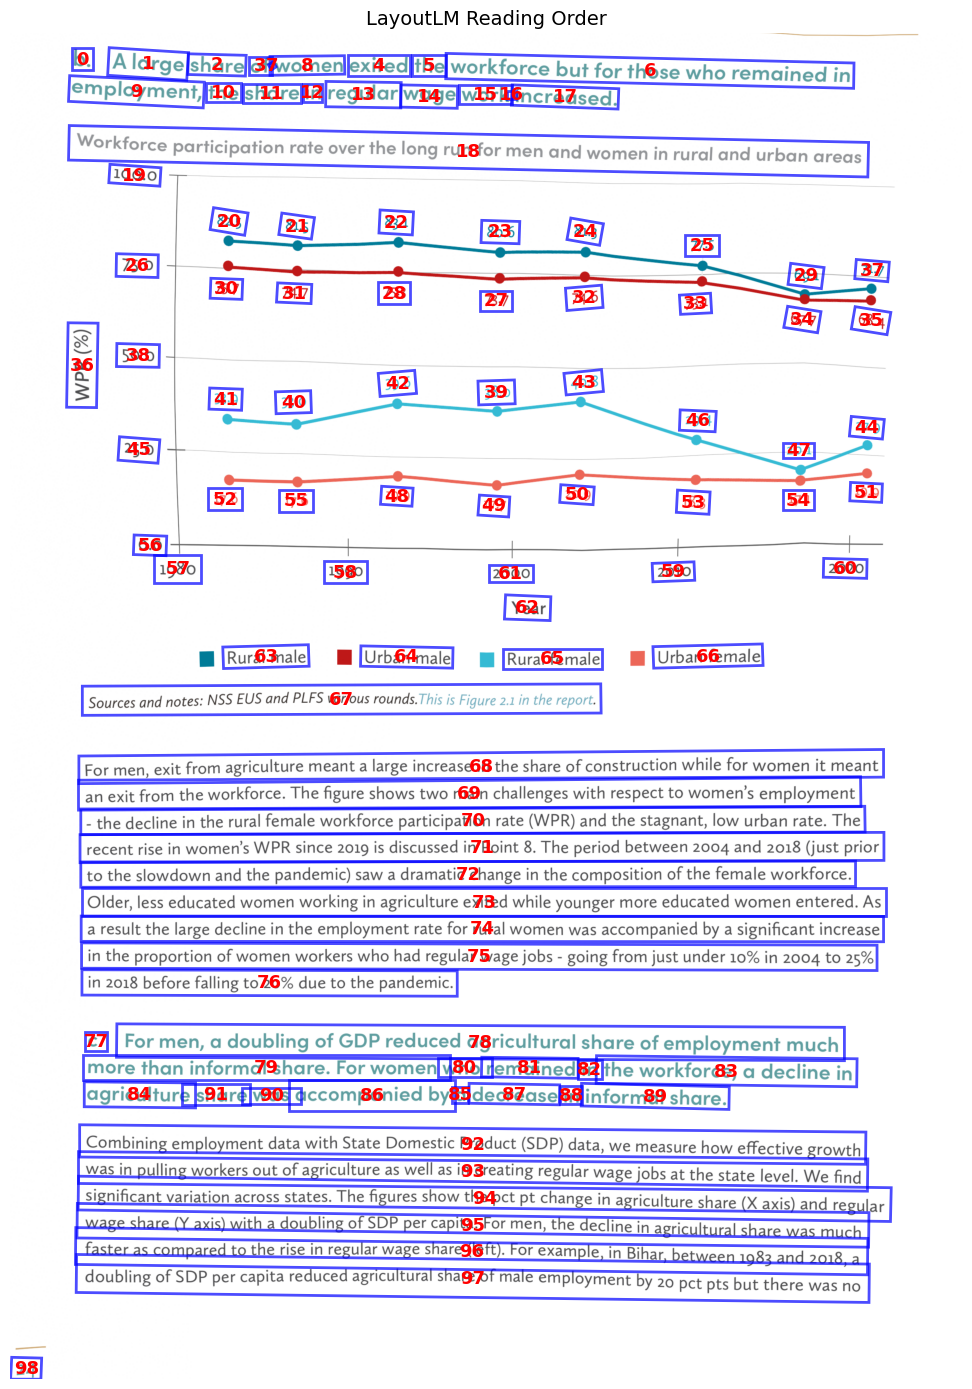

In [16]:
import matplotlib.patches as patches

def visualize_reading_order(ocr_regions, image_array, reading_order, title="Reading Order"):
    """
    Visualize OCR regions with their reading order numbers using matplotlib.
    """
    
    fig, ax = plt.subplots(1, figsize=(10, 14))
    ax.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
    
    # Create order mapping: index -> reading order position
    order_map = {i: order for i, order in enumerate(reading_order)}
    
    for i, region in enumerate(ocr_regions):
        bbox = region.bbox
        if bbox and len(bbox) >= 4:
            # Draw polygon
            ax.add_patch(patches.Polygon(bbox, linewidth=2, 
                                         edgecolor='blue',
                                         facecolor='none', alpha=0.7))
            # Add reading order number at center
            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            ax.text(sum(xs)/len(xs), sum(ys)/len(ys), 
                    str(order_map.get(i, i)),
                    fontsize=13, color='red', 
                    ha='center', va='center', fontweight='bold')
    
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_reading_order(ocr_regions, processed_img, 
                        reading_order, "LayoutLM Reading Order")

In [17]:
# Create ordered text content
def get_ordered_text(ocr_regions, reading_order):
    """
    Return OCR regions sorted by reading order
    with their text and confidence.
    """
    # 1. Create (reading_position, index, region) tuples and sort
    indexed_regions = [(reading_order[i], 
                        i, 
                        ocr_regions[i]) for i in range(len(ocr_regions))]
    
    # 2. Sort by reading position
    indexed_regions.sort(key=lambda x: x[0])  
    
    # 3. Extract ordered text info
    ordered_text = []
    for position, original_idx, region in indexed_regions:
        ordered_text.append({
            "position": position,
            "text": region.text,
            "confidence": region.confidence,
            "bbox": region.bbox_xyxy
        })
    
    return ordered_text

ordered_text = get_ordered_text(ocr_regions, reading_order)

print("Text in reading order:")
print("=" * 70)
ordered_text[:5]

Text in reading order:


[{'position': 0,
  'text': 'b.',
  'confidence': 0.9996724724769592,
  'bbox': [160, 39, 216, 97]},
 {'position': 1,
  'text': 'A large',
  'confidence': 0.9988369345664978,
  'bbox': [254, 38, 465, 123]},
 {'position': 2,
  'text': 'share',
  'confidence': 0.9998990893363953,
  'bbox': [463, 54, 615, 112]},
 {'position': 3,
  'text': 'of',
  'confidence': 0.9998925924301147,
  'bbox': [622, 62, 682, 109]},
 {'position': 4,
  'text': 'exited',
  'confidence': 0.9999249577522278,
  'bbox': [880, 57, 1041, 111]}]

In [18]:
from paddleocr import LayoutDetection

# Initialize layout detection 
layout_engine = LayoutDetection()

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-DocLayout_plus-L`.


In [19]:
# Process document layout 
def process_document(image_path):
    """Get layout regions from document."""
    layout_result = layout_engine.predict(image_path)
    
    regions = []
    for box in layout_result[0]['boxes']:
        regions.append({
            'label': box['label'],
            'score': box['score'],
            'bbox': box['coordinate'],  # [x1, y1, x2, y2]
        })
    
    # Sort by confidence
    regions = sorted(regions, key=lambda x: x['score'], reverse=True)
    return regions

layout_results = process_document(image_path)

print(f"Detected {len(layout_results)} layout regions:")
for r in layout_results:
    print(f"  {r['label']:20} score: {r['score']:.3f}  bbox: {[int(x) for x in r['bbox']]}")

Detected 10 layout regions:
  text                 score: 0.981  bbox: [246, 2797, 2215, 3178]
  text                 score: 0.979  bbox: [245, 1862, 2204, 2444]
  chart                score: 0.970  bbox: [266, 504, 2195, 1655]
  header               score: 0.889  bbox: [272, 148, 657, 181]
  text                 score: 0.837  bbox: [246, 228, 2074, 346]
  number               score: 0.830  bbox: [113, 3342, 153, 3375]
  figure_title         score: 0.823  bbox: [262, 426, 2112, 471]
  text                 score: 0.663  bbox: [245, 2540, 2135, 2723]
  figure_title         score: 0.624  bbox: [266, 1700, 1517, 1741]
  paragraph_title      score: 0.508  bbox: [245, 2540, 2135, 2723]


In [20]:
@dataclass
class LayoutRegion:
    region_id: int
    region_type: str
    bbox: list  # [x1, y1, x2, y2]
    confidence: float
    
# Store layout regions in structured format
layout_regions: List[LayoutRegion] = []
for i, r in enumerate(layout_results):
    layout_regions.append(LayoutRegion(
        region_id=i,
        region_type=r['label'],
        bbox=[int(x) for x in r['bbox']],
        confidence=r['score']
    ))

print(f"Stored {len(layout_regions)} layout regions")

Stored 10 layout regions


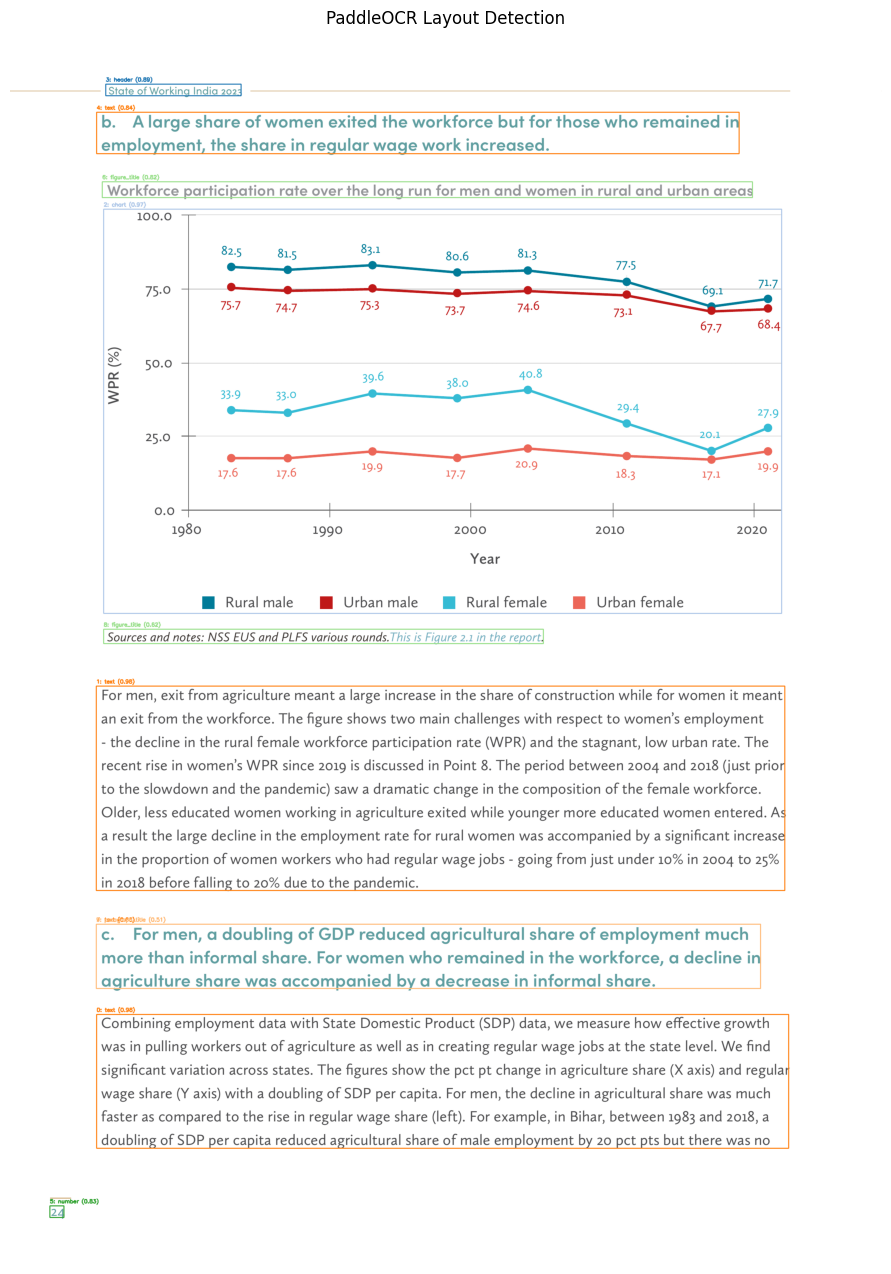

In [21]:
# Visualize layout detection 
from matplotlib import colormaps

def visualize_layout(image_path, layout_regions, min_confidence=0.5, 
                     title="Layout Detection"):
    """
    Visualize layout detection results using cv2 (same pattern as L2).
    """
    img = cv2.imread(image_path)
    img_plot = img.copy()
    
    # Get unique labels and generate colors
    labels = list(set(r.region_type for r in layout_regions))
    cmap = colormaps.get_cmap('tab20')
    color_map = {}
    for i, label in enumerate(labels):
        rgba = cmap(i % 20)
        color_map[label] = (int(rgba[2]*255), int(rgba[1]*255), int(rgba[0]*255))
    
    for region in layout_regions:
        if region.confidence < min_confidence:
            continue
            
        color = color_map[region.region_type]
        x1, y1, x2, y2 = region.bbox
        
        # Draw rectangle
        pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=int)
        cv2.polylines(img_plot, [pts], True, color, 2)
        
        # Add label
        text = f"{region.region_id}: {region.region_type} ({region.confidence:.2f})"
        cv2.putText(img_plot, text, (x1, y1-8), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    plt.figure(figsize=(12, 16))
    plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()
    
    return img_plot

visualize_layout(image_path, layout_regions, 
                 min_confidence=0.5, title="PaddleOCR Layout Detection");

In [22]:
import base64
from io import BytesIO

# Crop and save layout regions for agent tools
def crop_region(image, bbox, padding=10):
    """Crop a region from image with optional padding."""
    x1, y1, x2, y2 = bbox
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image.width, x2 + padding)
    y2 = min(image.height, y2 + padding)
    return image.crop((x1, y1, x2, y2))

def image_to_base64(img):
    """Convert PIL Image to base64 string."""
    buffer = BytesIO()
    img.save(buffer, format='PNG')
    return base64.b64encode(buffer.getvalue()).decode('utf-8')

# Load image for cropping
pil_image = Image.open(image_path)

# Store cropped regions in dictionary
region_images = {}
for region in layout_regions:
    cropped = crop_region(pil_image, region.bbox)
    region_images[region.region_id] = {
        'image': cropped,
        'base64': image_to_base64(cropped),
        'type': region.region_type,
        'bbox': region.bbox
    }

print(f"Cropped {len(region_images)} regions")

# Also store full image
full_image_base64 = image_to_base64(pil_image)

Cropped 10 regions


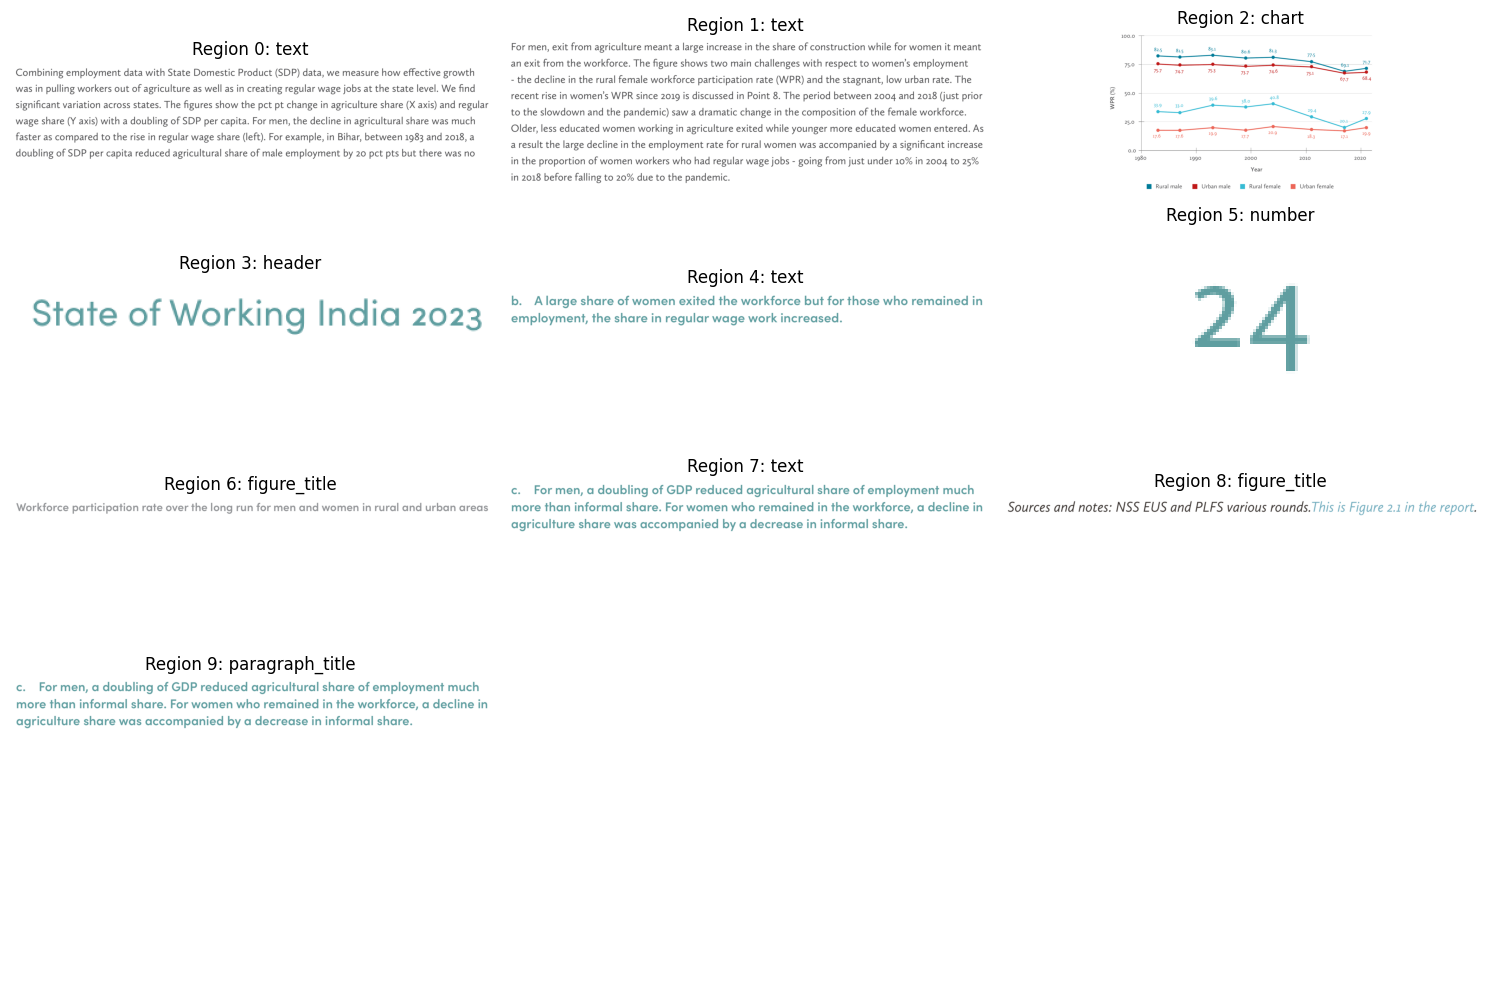

In [23]:
# Show cropped regions
fig, axes = plt.subplots(5, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (region_id, data) in enumerate(list(region_images.items())[:14]):
    axes[i].imshow(data['image'])
    axes[i].set_title(f"Region {region_id}: {data['type']}")
    axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [24]:
# groq AI
from groq import Groq
import os

groq_client = Groq(api_key=os.environ["GOOGLE_API_KEY"])  # add to .env

In [25]:
# Tool prompts
CHART_ANALYSIS_PROMPT = """You are a Chart Analysis specialist. 
Analyze this chart/figure image and extract:
1. **Chart Type**: (line, bar, scatter, pie, etc.)
2. **Title**: (if visible)
3. **Axes**: X-axis label, Y-axis label, and tick values
4. **Data Points**: Key values (peaks, troughs, endpoints)
5. **Trends**: Overall pattern description
6. **Legend**: (if present)
Return a JSON object with this structure:
```json
{{
  "chart_type": "...",
  "title": "...",
  "x_axis": {{"label": "...", "ticks": [...]}},
  "y_axis": {{"label": "...", "ticks": [...]}},
  "key_data_points": [...],
  "trends": "...",
  "legend": [...]
}}
```
"""

In [26]:
TABLE_ANALYSIS_PROMPT = """You are a Table Extraction specialist. 
Extract structured data from this table image.

1. **Identify Structure**: 
    - Column headers, row labels, data cells
2. **Extract All Data**: 
    - Preserve exact values and alignment
3. **Handle Special Cases**: 
    - Merged cells, empty cells (mark as null), multi-line headers

Return a JSON object with this structure:
```json
{{
  "table_title": "...",
  "column_headers": ["header1", "header2", ...],
  "rows": [
    {{"row_label": "...", "values": [val1, val2, ...]}},
    ...
  ],
  "notes": "any footnotes or source info"
}}
```
"""

In [27]:
def call_vlm_with_image(image_base64, prompt):
    response = groq_client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_base64}"}}
            ]
        }]
    )
    return response.choices[0].message.content

In [28]:
@tool
def AnalyzeChart(region_id: int) -> str:
    """Analyze a chart or figure region using VLM. 
    Use this tool when you need to extract data from charts, graphs, or figures.
    
    Args:
        region_id: The ID of the layout region to analyze (must be a chart/figure type)
    
    Returns:
        JSON string with chart type, axes, data points, and trends
    """
    if region_id not in region_images:
        return f"Error: Region {region_id} not found. Available regions: {list(region_images.keys())}"
    
    region_data = region_images[region_id]
    
    if region_data['type'] not in ['chart', 'figure']:
        return f"Warning: Region {region_id} is type '{region_data['type']}', not a chart/figure. Proceeding anyway."
    
    result = call_vlm_with_image(region_data['base64'], CHART_ANALYSIS_PROMPT)
    
    return result

print("AnalyzeChart tool defined")

AnalyzeChart tool defined


In [29]:
# Test the tools
print("Testing AnalyzeChart...")
chart_regions = [r for r in layout_regions if r.region_type in ['chart', 'figure']]
if chart_regions:
    test_result = AnalyzeChart.invoke({"region_id": chart_regions[0].region_id})
    print(f"Chart analysis result:\n{test_result[:500]}...")
else:
    print("No chart regions found")

Testing AnalyzeChart...
Chart analysis result:
Here is the JSON object with the extracted information:

```json
{
  "chart_type": "line",
  "title": "",
  "x_axis": {
    "label": "Year",
    "ticks": [1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
  },
  "y_axis": {
    "label": "WPR (%)",
    "ticks": [0.0, 25.0, 50.0, 75.0, 100.0]
  },
  "key_data_points": [
    {"Rural male": 82.5, "Urban male": 75.7, "Rural female": 33.9, "Urban female": 17.6},
    {"Rural male": 81.5, "Urban male": 74.7, "Rural female": 33.0, "Urban female": 17....


In [30]:
TABLE_ANALYSIS_PROMPT = """You are a Table Analysis specialist.
Analyze this table image and extract:
1. **Headers**: Column and row headers
2. **Data**: All cell values in a structured format
3. **Units**: Any units mentioned
4. **Notes**: Any footnotes or annotations

Return a JSON object with this structure:
```json
{{
  "headers": {{"columns": [...], "rows": [...]}},
  "data": [
    {{"row": "...", "values": {{...}}}}
  ],
  "units": "...",
  "notes": "..."
}}
```
"""

@tool
def AnalyzeTable(region_id: int) -> str:
    """Analyze a table region and extract structured data."""
    if region_id not in region_images:
        return f"Error: Region {region_id} not found."
    
    region_data = region_images[region_id]
    if region_data['type'] != 'table':
        return f"Warning: Region {region_id} is type '{region_data['type']}', not a table. Proceeding anyway."
    
    result = call_vlm_with_image(region_data['base64'], TABLE_ANALYSIS_PROMPT)
    return result

In [39]:
def call_vlm_with_image(image_base64, prompt):
    image_data = base64.b64decode(image_base64)
    image = Image.open(BytesIO(image_data))
    
    response = groq_client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_base64}"}}
            ]
        }]
    )
    return response.choices[0].message.content

@tool
def AnalyzeChart(region_id: int) -> str:
    """Analyze a chart/figure region and extract structured data."""
    if region_id not in region_images:
        return f"Error: Region {region_id} not found."
    
    region_data = region_images[region_id]
    if region_data['type'] not in ['chart', 'figure']:
        return f"Warning: Region {region_id} is type '{region_data['type']}', not a chart/figure. Proceeding anyway."
    
    result = call_vlm_with_image(region_data['base64'], CHART_ANALYSIS_PROMPT)
    return result

In [32]:
print("Testing AnalyzeTable...")
table_regions = [r for r in layout_regions if r.region_type == 'table']
if table_regions:
    test_result = AnalyzeTable.invoke({"region_id": table_regions[0].region_id})
    print(f"Table analysis result:\n{test_result[:500]}...")
else:
    print("No table regions found")

Testing AnalyzeTable...
No table regions found


In [33]:
#Prepare context for the agent
def format_ordered_text(ordered_text, max_items=50):
    """Format ordered text for the system prompt."""
    lines = []
    for item in ordered_text[:max_items]:
        lines.append(f"[{item['position']}] {item['text']}")
    
    if len(ordered_text) > max_items:
        lines.append(f"... and {len(ordered_text) - max_items} more text regions")
    
    return "\n".join(lines)

def format_layout_regions(layout_regions):
    """Format layout regions for the system prompt."""
    lines = []
    for region in layout_regions:
        lines.append(f"  - Region {region.region_id}: {region.region_type} (confidence: {region.confidence:.3f})")
    return "\n".join(lines)

# Create the formatted strings
ordered_text_str = format_ordered_text(ordered_text)
layout_regions_str = format_layout_regions(layout_regions)

print("Formatted context for agent:")
print(f"- Ordered text: {len(ordered_text_str)} chars")
print(f"- Layout regions: {len(layout_regions_str)} chars")

Formatted context for agent:
- Ordered text: 652 chars
- Layout regions: 421 chars


In [34]:
# System prompt for the agent
SYSTEM_PROMPT = f"""You are a Document Intelligence Agent. 
You analyze documents by combining OCR text with visual analysis tools.

## Document Text (in reading order)
The following text was extracted using OCR and ordered using LayoutLM.

{ordered_text_str}

## Document Layout Regions
The following regions were detected in the document:

{layout_regions_str}

## Your Tools
- **AnalyzeChart(region_id)**: 
    - Use for chart/figure regions to extract data points, axes, and trends
- **AnalyzeTable(region_id)**: 
    - Use for table regions to extract structured tabular data

## Instructions
1. For TEXT regions: 
    - Use the OCR text provided above (it's already extracted)
2. For TABLE regions: 
    - Use the AnalyzeTable tool to get structured data
3. For CHART/FIGURE regions: 
    - Use the AnalyzeChart tool to extract visual data

When answering questions about the document, 
use the appropriate tools to get accurate information.
"""

print("System prompt created")
print(f"Total length: {len(SYSTEM_PROMPT)} characters")

System prompt created
Total length: 1963 characters


In [35]:
from langchain_groq import ChatGroq

tools = [AnalyzeChart, AnalyzeTable]

# LLM for the agent - using Groq instead of OpenAI
agent_llm = ChatGroq(
    model="llama-3.3-70b-versatile",  # good reasoning model for agent use
    temperature=0,
    api_key=os.environ["GOOGLE_API_KEY"]
)

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import create_tool_calling_agent
from langchain.agents import AgentExecutor

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

agent = create_tool_calling_agent(agent_llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [36]:
# Test the agent with a simple question
response = agent_executor.invoke({
    "input": "What types of content are in this document?"
              "List the main sections.",
})
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...
The document contains the following types of content:

1. Text: The document has several text regions, including paragraphs and titles.
2. Chart/Figure: There is at least one chart/figure region, which is Region 2.
3. Header: Region 3 is detected as a header.
4. Number: Region 5 is detected as a number.
5. Figure Title: Regions 6 and 8 are detected as figure titles.
6. Paragraph Title: Region 9 is detected as a paragraph title.

The main sections of the document are:

1. Introduction/Text (Regions 0-1, 4, 7)
2. Chart/Figure (Region 2)
3. Header (Region 3)
4. Data/Numbers (Regions 5, 19-49)
5. Figure Titles (Regions 6, 8)
6. Paragraph Title (Region 9)

> Finished chain.

Agent Response:
The document contains the following types of content:

1. Text: The document has several text regions, including paragraphs and titles.
2. Chart/Figure: There is at least one chart/figure region, which is Region 2.
3. Header: Region 3 is detected as a header.
4. Nu

In [37]:
# Test with table extraction
response = agent_executor.invoke({
    "input": "Extract the data from the table in this document." 
             "Return it in a structured format."})
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `AnalyzeTable` with `{'region_id': 2}`


Invoking: `AnalyzeTable` with `{'region_id': 5}`


Invoking: `AnalyzeTable` with `{'region_id': 0}`
responded: Since there is no clear table region in the provided document layout, I will try to analyze the text regions to find any tabular data.

Upon examining the text regions, I notice that regions 18-49 contain numerical values that could be part of a table. However, without a clear table region, I will use the AnalyzeTable function on region 0, which is a text region with the highest confidence.



Invoking: `AnalyzeTable` with `{'region_id': 4}`


Invoking: `AnalyzeTable` with `{'region_id': 7}`


Invoking: `AnalyzeTable` with `{'region_id': 9}`



From the text regions, I can see that there are some numbers mentioned, but they are not in a structured table format. However, I can try to extract some data from the text.

For example, the text mentions "Workforce participation rate over the l

In [40]:
# Test with chart analysis
response = agent_executor.invoke({
    "input": "Analyze the chart/figure in this document." 
    "What trends does it show?"})
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `AnalyzeChart` with `{'region_id': 2}`


Here is the JSON object with the extracted information:

```json
{
  "chart_type": "line",
  "title": "",
  "x_axis": {
    "label": "Year",
    "ticks": [1980, 1990, 2000, 2010, 2020]
  },
  "y_axis": {
    "label": "WPR (%)",
    "ticks": [0.0, 25.0, 50.0, 75.0, 100.0]
  },
  "key_data_points": [
    {"Rural Male": 82.5, "Urban Male": 75.7, "Rural Female": 33.9, "Urban Female": 17.6},
    {"Rural Male": 81.5, "Urban Male": 74.7, "Rural Female": 33.0, "Urban Female": 17.6},
    {"Rural Male": 83.1, "Urban Male": 75.3, "Rural Female": 39.6, "Urban Female": 19.9},
    {"Rural Male": 80.6, "Urban Male": 73.7, "Rural Female": 38.0, "Urban Female": 17.7},
    {"Rural Male": 81.3, "Urban Male": 74.6, "Rural Female": 40.8, "Urban Female": 20.9},
    {"Rural Male": 77.5, "Urban Male": 73.1, "Rural Female": 29.4, "Urban Female": 18.3},
    {"Rural Male": 71.7, "Urban Male": 68.4, "Rural Female": 27.9, "

In [41]:
# Test with chart analysis
response = agent_executor.invoke({
    "input": "Can you make out what report/document is this page extracted from?"})
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...
This page appears to be extracted from a report related to workforce participation rates, possibly from a government or economic research institution. The text mentions workforce participation rates for men and women in rural and urban areas, and the presence of a chart or figure suggests that the report includes visual data to support its findings. However, without more context or information, it is difficult to determine the specific title or author of the report.

> Finished chain.

Agent Response:
This page appears to be extracted from a report related to workforce participation rates, possibly from a government or economic research institution. The text mentions workforce participation rates for men and women in rural and urban areas, and the presence of a chart or figure suggests that the report includes visual data to support its findings. However, without more context or information, it is difficult to determine the specific title or auth

In [42]:
# Test with chart analysis
response = agent_executor.invoke({
    "input": "Can you make out what report/document is this page extracted from."
   "what does header 3 indicate"})
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `AnalyzeChart` with `{'region_id': 2}`


Here is the analysis of the chart:

```json
{
  "chart_type": "line",
  "title": "",
  "x_axis": {
    "label": "Year",
    "ticks": [1980, 1990, 2000, 2010, 2020]
  },
  "y_axis": {
    "label": "WPR (%)",
    "ticks": [0.0, 25.0, 50.0, 75.0, 100.0]
  },
  "key_data_points": [
    {"Rural male": 82.5, "year": 1980},
    {"Rural male": 71.7, "year": 2020},
    {"Urban male": 75.7, "year": 1980},
    {"Urban male": 68.4, "year": 2020},
    {"Rural female": 33.9, "year": 1980},
    {"Rural female": 27.9, "year": 2020},
    {"Urban female": 17.6, "year": 1980},
    {"Urban female": 19.9, "year": 2020}
  ],
  "trends": "The chart shows a general decline in WPR for all groups over the years, with some fluctuations. Rural male WPR decreased from 82.5% in 1980 to 71.7% in 2020. Urban male WPR decreased from 75.7% in 1980 to 68.4% in 2020. Rural female WPR increased from 33.9% in 1980 to a peak of 40.8%

In [43]:
# Test with chart analysis
response = agent_executor.invoke({
    "input": "how did doubling of GDP affect men's agricultural employment share."
   })
print("\n" + "="*60)
print("Agent Response:")
print("="*60)
print(response["output"])



> Entering new AgentExecutor chain...

Invoking: `AnalyzeChart` with `{'region_id': 2}`


Here is the JSON object with the extracted information:

```json
{
  "chart_type": "line",
  "title": "",
  "x_axis": {
    "label": "Year",
    "ticks": [1980, 1990, 2000, 2010, 2020]
  },
  "y_axis": {
    "label": "WPR (%)",
    "ticks": [0.0, 25.0, 50.0, 75.0, 100.0]
  },
  "key_data_points": [
    {"Rural male": 82.5, "Urban male": 75.7, "Rural female": 33.9, "Urban female": 17.6},
    {"Rural male": 81.5, "Urban male": 74.7, "Rural female": 33.0, "Urban female": 17.6},
    {"Rural male": 83.1, "Urban male": 75.3, "Rural female": 39.6, "Urban female": 19.9},
    {"Rural male": 80.6, "Urban male": 73.7, "Rural female": 38.0, "Urban female": 17.7},
    {"Rural male": 81.3, "Urban male": 74.6, "Rural female": 40.8, "Urban female": 20.9},
    {"Rural male": 77.5, "Urban male": 73.1, "Rural female": 29.4, "Urban female": 18.3},
    {"Rural male": 69.1, "Urban male": 67.7, "Rural female": 20.1, "

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kkm7st25fvctqyd4p2fnmz9v` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 97646, Requested 3678. Please try again in 19m3.936s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}